In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping


In [ ]:
# Dataset base path
base_path = r"/content/drive/MyDrive/Colab Notebooks/Dataset_BUSI_with_GT"

# Categories
tumor_types = ["benign", "malignant", "normal"]

# Verify
print("Folders:", os.listdir(base_path))


Folders: ['normal', 'benign', 'malignant']


In [ ]:
# Image size & batch size
img_size = (128, 128)
batch_size = 32

# Data augmentation for training
train_datagen = ImageDataGenerator(
    rescale=1./255,          # normalize pixels
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    validation_split=0.2     # 80% train / 20% validation
)

# Training data
train_gen = train_datagen.flow_from_directory(
    base_path,
    target_size=img_size,
    batch_size=batch_size,
    class_mode="categorical",
    subset="training"
)

# Validation data
val_gen = train_datagen.flow_from_directory(
    base_path,
    target_size=img_size,
    batch_size=batch_size,
    class_mode="categorical",
    subset="validation"
)


Found 1263 images belonging to 3 classes.
Found 315 images belonging to 3 classes.


In [ ]:
# model = Sequential([
#     Conv2D(32, (3,3), activation="relu", input_shape=(128,128,3)),
#     MaxPooling2D(2,2),

#     Conv2D(64, (3,3), activation="relu"),
#     MaxPooling2D(2,2),

#     Conv2D(128, (3,3), activation="relu"),
#     MaxPooling2D(2,2),

#     Flatten(),
#     Dense(128, activation="relu"),
#     Dropout(0.5),
#     Dense(3, activation="softmax")   # 3 classes
# ])

# model.compile(optimizer="adam",
#               loss="categorical_crossentropy",
#               metrics=["accuracy"])

# model.summary()
# early_stop = EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)

# history = model.fit(
#     train_gen,
#     validation_data=val_gen,
#     epochs=20,
#     callbacks=[early_stop]
# )
# from tensorflow.keras.models import Sequential
# from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
# from tensorflow.keras.callbacks import EarlyStopping

# # CNN Model (same structure as yours)
# model = Sequential([
#     Conv2D(32, (3,3), activation="relu", input_shape=(128,128,3)),
#     MaxPooling2D(2,2),

#     Conv2D(64, (3,3), activation="relu"),
#     MaxPooling2D(2,2),

#     Conv2D(128, (3,3), activation="relu"),
#     MaxPooling2D(2,2),

#     Flatten(),
#     Dense(128, activation="relu"),
#     Dropout(0.5),
#     Dense(3, activation="softmax")   # 3 classes
# ])

# # Compile
# model.compile(optimizer="adam",
#               loss="categorical_crossentropy",
#               metrics=["accuracy"])

# # Show summary
# model.summary()

# # Early stopping
# early_stop = EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True)

# # Train faster: reduce epochs + smaller batch
# history = model.fit(
#     train_gen,
#     validation_data=val_gen,
#     epochs=20,              # reduced from 20 → 5
#     batch_size=16,         # smaller batch for quicker updates
#     callbacks=[early_stop],
#     verbose=1
# )
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

# CNN Model
model = Sequential([
    Conv2D(32, (3,3), activation="relu", input_shape=(128,128,3)),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation="relu"),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation="relu"),
    MaxPooling2D(2,2),

    Flatten(),
    Dense(128, activation="relu"),
    Dropout(0.5),
    Dense(3, activation="softmax")   # 3 classes
])

# Compile
model.compile(optimizer="adam",
              loss="categorical_crossentropy",
              metrics=["accuracy"])

# Show summary
model.summary()

# # Early stopping
# early_stop = EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True)

# # Train (20 epochs)
# history = model.fit(
#     train_gen,
#     validation_data=val_gen,
#     epochs=20,            # now full 20 epochs
#     batch_size=16,        # keep batch size fixed
#     callbacks=[early_stop],
#     verbose=1
# early_stop = EarlyStopping(monitor="val_loss", patience=20, restore_best_weights=True)

history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=40,
    batch_size=16,
    callbacks=[early_stop],
    verbose=1
)




Model: "sequential_13"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_39 (Conv2D)              │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_39 (MaxPooling2D) │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_40 (Conv2D)              │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_40 (MaxPooling2D) │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_41 (Conv2D)              │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_41 (MaxPooling2D) │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_13 (Flatten)            │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_26 (Dense)                │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_27 (Dense)                │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,305,027 (12.61 MB)

 Trainable params: 3,305,027 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 25s 540ms/step - accuracy: 0.5209 - loss: 0.9370 - val_accuracy: 0.6730 - val_loss: 0.8134
Epoch 2/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 19s 487ms/step - accuracy: 0.6371 - loss: 0.8301 - val_accuracy: 0.6762 - val_loss: 0.7249
Epoch 3/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 18s 457ms/step - accuracy: 0.6820 - loss: 0.7313 - val_accuracy: 0.6794 - val_loss: 0.7050
Epoch 4/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 18s 454ms/step - accuracy: 0.6704 - loss: 0.7041 - val_accuracy: 0.6794 - val_loss: 0.6617
Epoch 5/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 17s 434ms/step - accuracy: 0.7102 - loss: 0.6786 - val_accuracy: 0.7111 - val_loss: 0.6438
Epoch 6/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 19s 487ms/step - accuracy: 0.7035 - loss: 0.6325 - val_accuracy: 0.7111 - val_loss: 0.6359
Epoch 7/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 17s 435ms/step - accuracy: 0.6937 - loss: 0.6649 - val_accuracy: 0.6952 - val_loss: 0.6585
Epoch 8/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 21s 447ms/step - accuracy: 0.7325 - loss: 0.6282 - val_accu

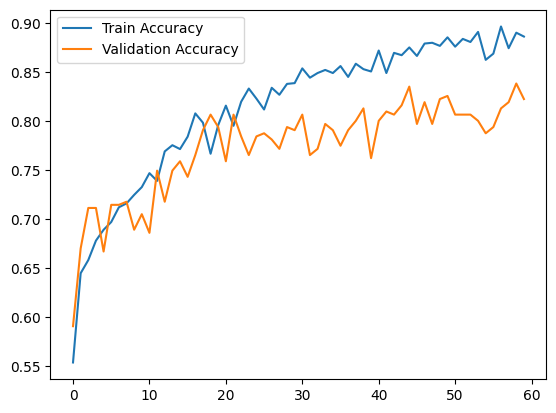

10/10 ━━━━━━━━━━━━━━━━━━━━ 4s 416ms/step - accuracy: 0.8170 - loss: 0.4622
✅ Validation Accuracy: 81.27%


In [ ]:
# Plot accuracy
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.show()

# Evaluate on validation set
val_loss, val_acc = model.evaluate(val_gen)
print(f"✅ Validation Accuracy: {val_acc*100:.2f}%")


In [ ]:
model.save("breast_cancer_detection_busi.h5")
print("✅ Model saved as breast_cancer_detection_busi.h5")


✅ Model saved as breast_cancer_detection_busi.h5


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 543ms/step


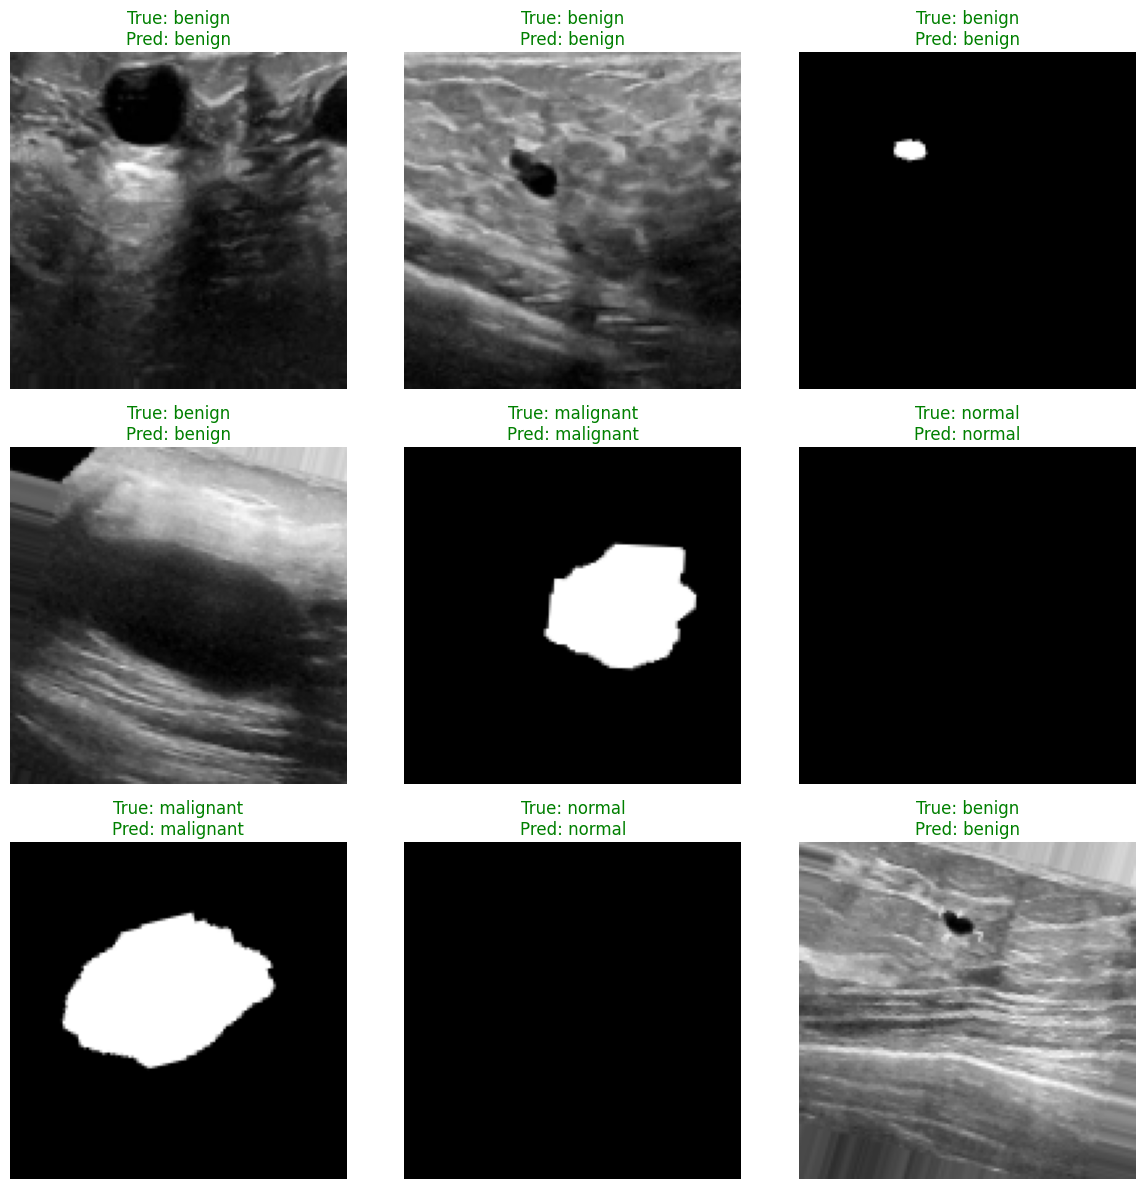

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import random

# Get class labels from generator
class_labels = list(train_gen.class_indices.keys())

# Pick some random images from validation set
x, y_true = next(val_gen)   # one batch of images
y_pred = model.predict(x)   # predictions
y_pred_classes = np.argmax(y_pred, axis=1)
y_true_classes = np.argmax(y_true, axis=1)

# Plot first 9 images with predictions
plt.figure(figsize=(12, 12))
for i in range(9):
    plt.subplot(3, 3, i+1)
    plt.imshow(x[i])  # show image
    plt.axis("off")

    true_label = class_labels[y_true_classes[i]]
    pred_label = class_labels[y_pred_classes[i]]

    color = "green" if true_label == pred_label else "red"
    plt.title(f"True: {true_label}\nPred: {pred_label}", color=color)

plt.tight_layout()
plt.show()
